# Crop Recommendation Using Machine Learning

## 1. Introduction

Choosing the right crop for the right soil can make farming more efficient and sustainable.

This project explores how soil characteristics can influence crop selection by identifying which individual soil measurement (Nitrogen, Phosphorous, Potassium, or pH), provides the strongest predictive signal for determining the most suitable crop type.
The focus is on generating clear insights that highlight which variable carries the most strategic importance.

This notebook covers:
* Loading and understanding the dataset
* Exploring the distribution of soil features
* Training simple baseline models using one feature at a time
* Comparing their performance
* Identifying the most predictive soil measurement

The final result highlights **which soil property contributes most strongly to crop prediction**, offering practical value both for agricultural decision-making and for exploratory data science workflows.


###Dataset Overview:

The dataset used in this project `soil_measures.csv` contains soil measurements and the recommended best crop for each sample. The four numerical features are:

* **N**: Nitrogen level
* **P**: Phosphorous level
* **K**: Potassium level
* **pH**: Acidity or alkalinity of the soil

Each row represents a field sample, and the target variable indicates which crop is most suitable given those soil conditions.

## 2. Imports

In this section, I import the libraries used for data manipulation, visualization, and model training.

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

## 3. Dataset Loading

The dataset is stored in Google Drive, so I begin by mounting the drive and loading the CSV file.

In [33]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/_Notebooks/Predictive Modeling for Agriculture/soil_measures.csv'
crops = pd.read_csv(file_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 4. Dataset Inspection

Before starting the exploratory analysis, I check the structure of the dataset, including data types, basic statistics, and an overview of the crop categories. This helps confirm that the data is clean and understand the variables we are working with.

In [34]:
# Preview the first rows
crops.head()

,N,P,K,ph,crop
0,90,42,43,6.502985,rice
1,85,58,41,7.038096,rice
2,60,55,44,7.840207,rice
3,74,35,40,6.980401,rice
4,78,42,42,7.628473,rice


In [35]:
# Dataset sumary
crops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       2200 non-null   int64  
 1   P       2200 non-null   int64  
 2   K       2200 non-null   int64  
 3   ph      2200 non-null   float64
 4   crop    2200 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 86.1+ KB


In [36]:
# Basic statistics
crops.describe().round(2)

,N,P,K,ph
count,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,6.47
std,36.92,32.99,50.65,0.77
min,0.00,5.00,5.00,3.50
25%,21.00,28.00,20.00,5.97
50%,37.00,51.00,32.00,6.43
75%,84.25,68.00,49.00,6.92
max,140.00,145.00,205.00,9.94


In [37]:
# Crop categories: Unique values of 'crop' feature
crops['crop'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

## 5. EDA: Distribution of each Feature

Before training any model, I look at the distribution of each soil measurement (N, P, K, and pH). The goal is to understand their value ranges, spot any unusual patterns, and get a sense of how these variables vary across the dataset.

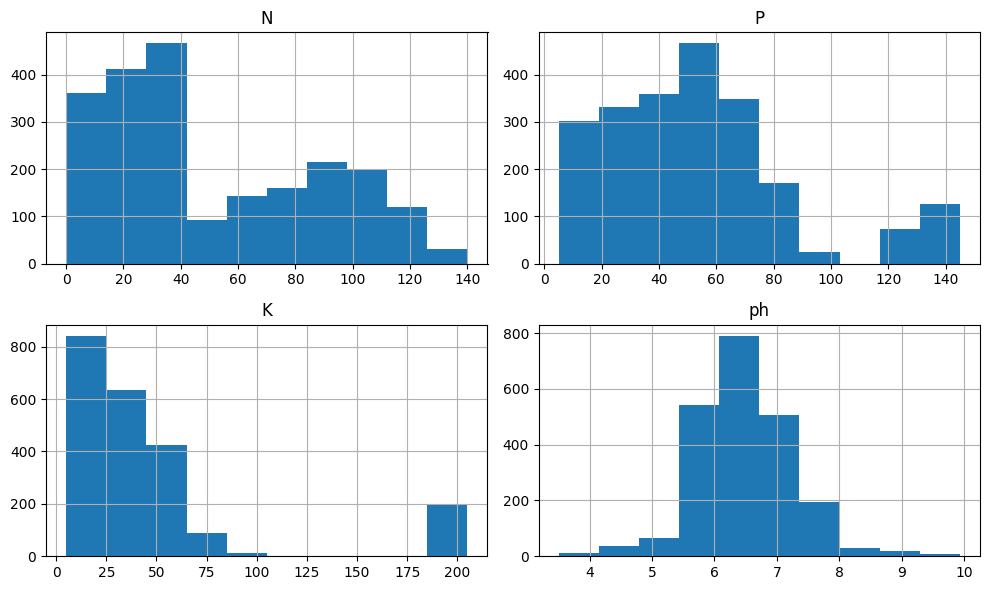

In [38]:
crops[['N', 'P', 'K', 'ph']].hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

#### Observations

**Nitrogen (N)**: distributed across a wide range, indicating diverse soil conditions.

**Phosphorous (P)**: more concentrated in specific ranges.

**Potassium (K)**: wide spread, which aligns with its strong predictive impact later.

**pH**: stays within realistic agricultural values (around acidic to slightly alkaline soils).

## 6. Correlation Check

Before modeling, t’s useful to check how the soil features relate to each other. This helps confirm whether each variable provides unique information or if some of them overlap.

#### Correlation Matrix

In [39]:
crops[['N', 'P', 'K', 'ph']].corr().round(2)

,N,P,K,ph
N,1.00,-0.23,-0.14,0.10
P,-0.23,1.00,0.74,-0.14
K,-0.14,0.74,1.00,-0.17
ph,0.10,-0.14,-0.17,1.00


#### Heatmap

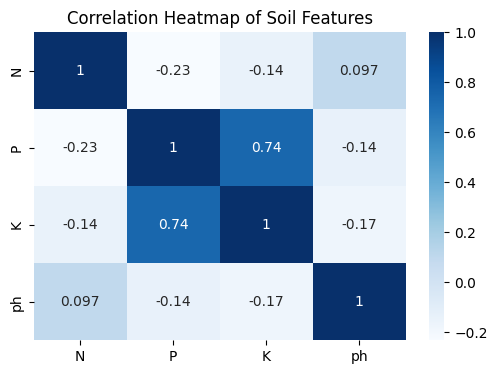

In [40]:
plt.figure(figsize=(6,4))
sns.heatmap(crops[['N','P','K','ph']].corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap of Soil Features")
plt.show()

#### Observations

* The soil features show **weak correlations**, meaning they behave mostly independently.

* This supports the modeling approach of evaluating each feature individually.

## 7. Train–Test Split

Before training any model, we prepare the data by separating the features from the target and creating training and testing subsets.

In [41]:
# Define features and target
y = crops['crop']
X = crops[['N','P','K','ph']]

In [42]:
# Split into Training and Test Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

* **X** contains the soil measurements (our input features).
* **y** contains the crop type (the target we want to predict).
* I split the data into training (80%) and testing (20%) so we can evaluate the model on data it has never seen before.

## 8. Model Training: Logistic Regression (Single Feature)

Here, I train a Logistic Regression model using **one feature at a time**.
The goal is to compare the performance of each soil variable (N, P, K, and ph) and identify which one is the strongest single predictor of the crop type.

In [43]:
# Dictionary to store the model performance for each feature
feature_performance = {}

# Train a logistic regression model for each feature
for feature in ['N','P','K','ph']:
    model = LogisticRegression(max_iter = 10000)

    model.fit(X_train[[feature]] ,y_train)
    predictions = model.predict(X_test[[feature]]) # predict target values with the test set

    acc = metrics.accuracy_score(y_test, predictions)   # calculate accuracy score
    feature_performance[feature] = acc             # add to the dictionary

feature_performance


{'N': 0.1431818181818182,
 'P': 0.18863636363636363,
 'K': 0.24772727272727274,
 'ph': 0.09772727272727273}

**Explanation**:

Each model is trained using only one soil variable.
This approach allows clear comparison between features and shows which single variable provides the best predictive signal.

## 9. Identifying the Best Predictive Feature

After evaluating each feature,
I select the soil variable that achieved the highest performance.

In [44]:
# find the best feature
best_feature = max(feature_performance, key=feature_performance.get)
best_accuracy = feature_performance[best_feature]

print(f"Best Predictive Feature: '{best_feature}'")
print(f"with accuracy = {best_accuracy:.4f}")

Best Predictive Feature: 'K'
with accuracy = 0.2477


**Explanation:**
This step highlights which soil measurement carries the strongest predictive signal when used alone.
The result helps reveal which variable farmers should prioritize when making quick assessments about crop suitability.

## 10. Final Conclusions


After evaluating the predictive power of each soil feature (Nitrogen, Phosphorous, Potassium, and pH) using a consistent baseline model, the feature that delivered the highest accuracy was **Potassium (K)**.

This result suggests that potassium levels carry meaningful separative power and could support more informed agronomic planning, helping identify productivity drivers and guide strategic decisions related to soil management and crop selection.